## Section 1 — Install Dependencies

In [1]:
!pip install -q \
transformers==4.40.0 \
accelerate==0.29.0 \
peft==0.10.0 \
sympy==1.12 \
datasets evaluate rouge_score bert_score \
sacrebleu nltk sentencepiece \
plotly gradio scikit-learn

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
print('Dependencies installed ✓')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.3/297.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 761.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.5 MB/s eta 0:00:00
   ━━━━

## Section 2 — Imports & Constants

In [2]:
import os, re, json, shutil, warnings, random
import numpy as np
import pandas as pd
from pathlib import Path

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq, set_seed,
    EarlyStoppingCallback,   # ← ADD THIS
)
from peft import get_peft_model, LoraConfig, TaskType
import evaluate

import matplotlib.pyplot as plt
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
set_seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

OUTPUT_DIR      = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
BARTPHO_OUT_DIR = str(OUTPUT_DIR / 'bartpho_finetuned')
VIT5_OUT_DIR    = str(OUTPUT_DIR / 'vit5_finetuned')
VIT5_PREFIX     = 'tóm tắt: '

print('Imports done ✓')

Device : cuda
GPU    : Tesla T4
Imports done ✓


In [3]:
print("Loading prepared dataset...")

train_df_aug = pd.read_csv("train.csv")
val_df       = pd.read_csv("val.csv")

print(f"Train size : {len(train_df_aug)}")
print(f"Val size   : {len(val_df)}")

Loading prepared dataset...
Train size : 2553
Val size   : 106


## Section 4 — Dataset & Tokenization Utilities

In [4]:
class SummarizationDataset(Dataset):
    def __init__(self, df, tokenizer, max_input=1024, max_target=256, prefix=''):
        self.df        = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_input = max_input
        self.max_target= max_target
        self.prefix    = prefix

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        article = self.prefix + str(self.df.loc[idx, 'article'])
        summary = str(self.df.loc[idx, 'summary'])

        model_inputs = self.tokenizer(
            article,
            max_length=self.max_input,
            truncation=True,
            padding=False,
        )

        # REMOVE token_type_ids (BARTpho incompatible)
        model_inputs.pop("token_type_ids", None)

        labels = self.tokenizer(
            text_target=summary,
            max_length=self.max_target,
            truncation=True,
            padding=False,
        )

        model_inputs["labels"] = labels["input_ids"]
        return model_inputs


def compute_metrics_factory(tokenizer):
    rouge = evaluate.load('rouge')
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
        labels      = np.where(labels      != -100, labels,      tokenizer.pad_token_id)
        preds  = [p.strip() for p in tokenizer.batch_decode(predictions, skip_special_tokens=True)]
        refs   = [l.strip() for l in tokenizer.batch_decode(labels,      skip_special_tokens=True)]
        r = rouge.compute(predictions=preds, references=refs, use_stemmer=False)
        return {'rouge1': round(r['rouge1'],4), 'rouge2': round(r['rouge2'],4), 'rougeL': round(r['rougeL'],4)}
    return compute_metrics

print('Dataset utilities ready ✓')

Dataset utilities ready ✓


## Section 5 — Model 1: BARTpho-word Fine-tuning

**Architecture:** BART-large pretrained on 4 GB Vietnamese news (word-level tokenisation).  
**Why chosen:** Strong encoder-decoder for abstractive summarisation; same domain (news) as our data.  
**LoRA config:** `r=16, alpha=32`, targets `q_proj` & `v_proj` — ~0.5% of parameters trainable.  
**Generation:** beam search `n=4`, `length_penalty=1.5`, `no_repeat_ngram_size=3`.

No checkpoint found — training from scratch...
Parameters: 420,361,216
trainable params: 2,359,296 || all params: 422,720,512 || trainable%: 0.5581219583685592
Starting BARTpho fine-tuning…


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
0,4.366700,3.722301,0.478100,0.170200,0.265000
1,3.683600,3.241638,0.519700,0.183500,0.280600
2,3.397700,3.031410,0.589600,0.230500,0.301700
4,3.027100,2.785836,0.613300,0.255200,0.310900
5,2.877400,2.709907,0.612000,0.254400,0.311400
6,2.766800,2.662901,0.637100,0.272400,0.320400
8,2.614200,2.604655,0.635100,0.277300,0.323100
9,2.528700,2.598280,0.647700,0.284900,0.329000
10,2.504200,2.577240,0.663100,0.294500,0.337600
12,2.415600,2.562933,0.671500,0.302100,0.340400


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
0,4.366700,3.722301,0.478100,0.170200,0.265000
1,3.683600,3.241638,0.519700,0.183500,0.280600
2,3.397700,3.031410,0.589600,0.230500,0.301700
4,3.027100,2.785836,0.613300,0.255200,0.310900
5,2.877400,2.709907,0.612000,0.254400,0.311400
6,2.766800,2.662901,0.637100,0.272400,0.320400
8,2.614200,2.604655,0.635100,0.277300,0.323100
9,2.528700,2.598280,0.647700,0.284900,0.329000
10,2.504200,2.577240,0.663100,0.294500,0.337600
12,2.415600,2.562933,0.671500,0.302100,0.340400


BARTpho saved → outputs/bartpho_finetuned ✓
Running final evaluation...


Final metrics saved ✓


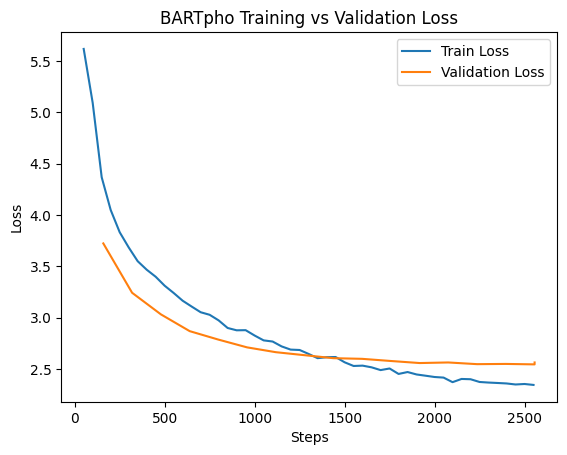

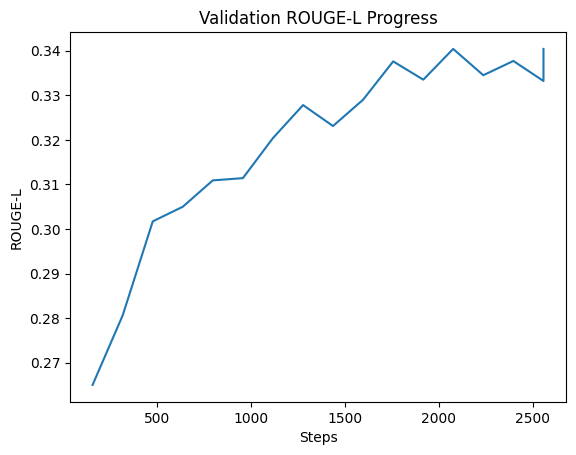

In [8]:
BARTPHO_MODEL = 'vinai/bartpho-word'

if Path(BARTPHO_OUT_DIR).exists() and any(Path(BARTPHO_OUT_DIR).iterdir()):
    print(f"BARTpho checkpoint found — skipping training, loading directly.")
    bartpho_tokenizer = AutoTokenizer.from_pretrained(BARTPHO_OUT_DIR)
    bartpho_model     = AutoModelForSeq2SeqLM.from_pretrained(BARTPHO_OUT_DIR).to(DEVICE)
    print("BARTpho loaded ✓")
else:
    print("No checkpoint found — training from scratch...")
    bartpho_tokenizer = AutoTokenizer.from_pretrained(BARTPHO_MODEL)
    bartpho_base      = AutoModelForSeq2SeqLM.from_pretrained(BARTPHO_MODEL)
    print(f"Parameters: {sum(p.numel() for p in bartpho_base.parameters()):,}")

    lora_cfg_bp = LoraConfig(
        task_type=TaskType.SEQ_2_SEQ_LM, r=16, lora_alpha=32,
        target_modules=['q_proj', 'v_proj'], lora_dropout=0.1, bias='none',
    )
    bartpho_model = get_peft_model(bartpho_base, lora_cfg_bp)
    bartpho_model.print_trainable_parameters()

    bartpho_train = SummarizationDataset(train_df_aug, bartpho_tokenizer)
    bartpho_val   = SummarizationDataset(val_df,       bartpho_tokenizer)
    collator_bp   = DataCollatorForSeq2Seq(bartpho_tokenizer, model=bartpho_model, padding=True, pad_to_multiple_of=8)

    args_bp = Seq2SeqTrainingArguments(
        output_dir=BARTPHO_OUT_DIR,
        num_train_epochs=20,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_ratio=0.15,
        weight_decay=0.01,
        lr_scheduler_type='cosine',
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='rougeL',
        greater_is_better=True,
        predict_with_generate=True,
        generation_max_length=256,
        fp16=torch.cuda.is_available(),
        logging_steps=50,
        report_to='none',
        save_total_limit=2,
    )

    trainer_bp = Seq2SeqTrainer(
        model=bartpho_model,
        args=args_bp,
        train_dataset=bartpho_train,
        eval_dataset=bartpho_val,
        tokenizer=bartpho_tokenizer,
        data_collator=collator_bp,
        compute_metrics=compute_metrics_factory(bartpho_tokenizer),
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=3,
                early_stopping_threshold=0.001
            )
        ],
    )

    print("Starting BARTpho fine-tuning…")
    trainer_bp.train()
    trainer_bp.save_model(BARTPHO_OUT_DIR)
    bartpho_tokenizer.save_pretrained(BARTPHO_OUT_DIR)
    print(f"BARTpho saved → {BARTPHO_OUT_DIR} ✓")
    print("Running final evaluation...")

    metrics = trainer_bp.evaluate()

    with open(f"{BARTPHO_OUT_DIR}/final_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    print("Final metrics saved ✓")

    # ===== Training history visualization =====

    log_history = trainer_bp.state.log_history
    history_df = pd.DataFrame(log_history)

    history_df.to_csv(f"{BARTPHO_OUT_DIR}/training_log.csv", index=False)

    train_logs = history_df[history_df["loss"].notna()]
    eval_logs  = history_df[history_df["eval_loss"].notna()]

    plt.figure()
    plt.plot(train_logs["step"], train_logs["loss"], label="Train Loss")
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], label="Validation Loss")

    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("BARTpho Training vs Validation Loss")
    plt.legend()
    plt.show()

    if "eval_rougeL" in eval_logs.columns:
        plt.figure()
        plt.plot(eval_logs["step"], eval_logs["eval_rougeL"])

        plt.xlabel("Steps")
        plt.ylabel("ROUGE-L")
        plt.title("Validation ROUGE-L Progress")
        plt.show()

In [9]:
# ===== Quick Sanity Check =====
print("=== Sample Predictions ===")

sample_df = pd.read_csv('test.csv').head(2)

def count_words(text):
    return len(str(text).split())

def extract_numbers(text):
    import re
    pattern = re.compile(r'\b\d{4}-\d{4}\b|\b\d{1,2}/\d{1,2}/\d{2,4}\b|\b\d{1,2}/\d{1,2}\b|\b\d+(?:[.,]\d+)*%?\b|\b\d+\s*-\s*\d+\b|\b\d+[hH]\d{2}\b')
    return set(pattern.findall(str(text)))

for idx, row in sample_df.iterrows():
    article = str(row['article'])
    reference = str(row['summary'])

    inputs = bartpho_tokenizer(article, return_tensors='pt', max_length=1024, truncation=True)
    inputs.pop('token_type_ids', None)
    inputs = inputs.to(DEVICE)

    aw = count_words(article)
    with torch.no_grad():
        out = bartpho_model.generate(
            **inputs,
            num_beams=4,
            length_penalty=0.8,
            min_length=max(10, int(aw * 0.20)),
            max_length=min(512, int(aw * 0.25)),
            early_stopping=True,
            no_repeat_ngram_size=3,
        )
    pred = bartpho_tokenizer.decode(out[0], skip_special_tokens=True)

    art_nums  = extract_numbers(article)
    pred_nums = extract_numbers(pred)
    missing   = art_nums - pred_nums
    ratio     = count_words(pred) / aw if aw > 0 else 0

    print(f'\n--- Sample {idx+1} ---')
    print(f'ARTICLE  : {article[:200]}...')
    print(f'REFERENCE: {reference}')
    print(f'PREDICTED: {pred}')
    print(f'Length ratio: {ratio:.2%} | Missing numbers: {missing or "none"}')

=== Sample Predictions ===

--- Sample 1 ---
ARTICLE  : Trước Trung Quốc đang xuống tinh thần sau ba trận toàn thua, HLV Shin Tae-yong vẫn thận trọng, cho Indonesia đá theo sơ đồ 5-4-1. Nhà cầm quân Hàn Quốc cũng dùng tới chín cầu thủ được nhập tịch vốn si...
REFERENCE: Trung Quốc giành chiến thắng đầu tiên tại vòng loại World Cup 2026 khi đánh bại Indonesia. Trước 10.000 khán giả nhà, họ chơi kiên cường dù đối thủ áp đảo với 75 phần trăm thời lượng kiểm soát bóng và thực hiện hơn 300 đường chuyền. Phút 21, Behram Abduweli mở tỷ số nhờ sai lầm hàng thủ khách. Phút 44, Zhang Yuning nhân đôi cách biệt sau đường kiến tạo của Gao Zhunyi, tình huống loại bỏ 5 cầu thủ đối phương. Indonesia sử dụng 9 cầu thủ nhập tịch và thay 4 vị trí sau giờ nghỉ nhưng bế tắc trước hệ thống phòng ngự 0 kẽ hở. Phút 87, số 19 Thom Haye ghi bàn rút ngắn cách biệt. Sau 2 hiệp đấu căng thẳng, Trung Quốc bảo vệ thành công tỷ số dù đối thủ dồn lên suốt 7 phút bù giờ. Trận đấu khép lại với kết quả 2-1 chung cuộc cho

In [10]:
!zip -r bartpho.zip outputs/bartpho_finetuned
from google.colab import files
files.download("bartpho.zip")

  adding: outputs/bartpho_finetuned/ (stored 0%)
  adding: outputs/bartpho_finetuned/training_args.bin (deflated 51%)
  adding: outputs/bartpho_finetuned/training_log.csv (deflated 57%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/ (stored 0%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/rng_state.pth (deflated 25%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/training_args.bin (deflated 51%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/trainer_state.json (deflated 77%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/scheduler.pt (deflated 55%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/bpe.codes (deflated 59%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/vocab.txt (deflated 55%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/optimizer.pt (deflated 9%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/added_tokens.json (stored 0%)
  adding: outputs/bartpho_finetuned/checkpoint-2556/adapter_model.safetensors (deflated 7%)
  adding: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>